## Questão 4 – Árvore de Decisão

**Enunciado:**  
Faça um código em Python para treinar e avaliar um modelo de Árvore de Decisão adequado ao problema da base escolhida. Controle profundidade, critérios de divisão e tamanho mínimo de amostras por nó, registrando os resultados em tabela. Depois, interprete a árvore gerada, identifique as variáveis mais relevantes nas divisões e discuta se a interpretabilidade do modelo compensa eventuais perdas de desempenho em comparação com os métodos testados anteriormente.

## Raciocínio

As análises anteriores já deixaram claro que o problema de churn da base Telco depende fortemente da interação entre atributos, e não apenas de efeitos isolados. Esse comportamento apareceu em diferentes momentos:

* Na **Q2**, o Naive Bayes teve desempenho limitado porque assume independência condicional entre variáveis que claramente são correlacionadas.
* Na **Q3**, a inclusão da interação `tenure × MonthlyCharges` produziu um aumento expressivo no R² da regressão.
* Já na **Lista 1**, atributos como `Contract`, `tenure` e `InternetService` apareceram como os fatores mais associados ao cancelamento.

Esses resultados indicam que o churn não depende de uma única variável, mas de combinações específicas de características do cliente. Em outras palavras, o risco aumenta quando certos fatores acontecem simultaneamente, como contratos mensais, pouco tempo de permanência e cobranças elevadas.

Nesse contexto, a Árvore de Decisão se torna uma escolha natural para esse tipo de problema porque consegue representar regras condicionais de forma hierárquica. Diferente do Naive Bayes, ela não assume independência entre atributos, e diferente da Regressão Logística tradicional, ela não depende apenas de relações lineares. Cada divisão da árvore representa uma pergunta objetiva sobre o cliente, formando caminhos interpretáveis até a classificação final.

A ideia principal é permitir que o modelo aprenda regras do tipo:

> clientes com contrato mensal, pouco tempo de permanência e cobrança elevada possuem risco de churn maior.

Para encontrar uma configuração equilibrada, foi realizada uma busca sistemática de hiperparâmetros variando:

| Hiperparâmetro     | Valores testados  |
| ------------------ | ----------------- |
| `max_depth`        | 3 a 8             |
| `criterion`        | `gini`, `entropy` |
| `min_samples_leaf` | 10, 30, 50        |

Isso gera **36 combinações diferentes**, todas avaliadas com validação cruzada estratificada (5-fold).

A utilização de validação estratificada mantém a proporção original de churn em cada divisão da base, algo importante devido ao desbalanceamento identificado na Q1. Assim como nas questões anteriores, a métrica principal escolhida foi o **F1-score**, já que ela representa melhor o equilíbrio entre precisão e recall da classe positiva (`Churn = Yes`).

Além da árvore otimizada para desempenho, também foi treinada uma segunda árvore com profundidade limitada a `max_depth = 4`, com foco exclusivamente em interpretabilidade.

A ideia não foi apenas obter a melhor métrica possível, mas também produzir regras compreensíveis para contexto de negócio, visto que em um cenário de retenção de clientes, entender *por que* um cliente foi classificado como risco alto pode ser tão importante quanto a classificação em si.


### Desenvolvimento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
TARGET = 'Churn'

In [2]:
# ── Pré-processamento herdado das questões anteriores ────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask_missing = df['TotalCharges'].isna()
df.loc[mask_missing, 'TotalCharges'] = (
    df.loc[mask_missing, 'MonthlyCharges'] * df.loc[mask_missing, 'tenure']
)
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Feature engineered da Lista 1 Q6 — as mais associadas ao churn
contract_map = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df['contract_numeric']           = df['Contract'].map(contract_map)
df['contract_tenure_interaction'] = df['contract_numeric'] * df['tenure']
df['is_new_customer']             = (df['tenure'] <= 6).astype(int)
df['service_adoption_count']      = sum(
    (df[c] == 'Yes').astype(int) for c in
    ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
     'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
) + (df['InternetService'] != 'No').astype(int)

# Codifica alvo
df['Churn_bin'] = (df[TARGET] == 'Yes').astype(int)

print(f'Base pronta: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Distribuição do alvo: {df["Churn_bin"].value_counts().to_dict()}')

Base pronta: 7043 linhas × 25 colunas
Distribuição do alvo: {0: 5174, 1: 1869}


In [3]:
# ── Separação features / alvo ─────────────────────────────────────────────────
EXCLUDE  = [TARGET, 'Churn_bin', 'contract_numeric']   # contract_numeric é auxiliar
X = df.drop(columns=EXCLUDE)
y = df['Churn_bin']

NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'contract_tenure_interaction', 'is_new_customer', 'service_adoption_count']
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'Features numéricas: {len(NUM_COLS)} | categóricas: {len(CAT_COLS)}')

Treino: 5634 | Teste: 1409
Features numéricas: 6 | categóricas: 16


In [4]:
# ── Busca sistemática de hiperparâmetros ─────────────────────────────────────
# Grade: max_depth × criterion × min_samples_leaf = 6 × 2 × 3 = 36 combinações
# Avaliação: F1 CV 5-fold estratificado (mesma métrica das questões anteriores)

grid = {
    'max_depth'       : [3, 4, 5, 6, 7, 8],
    'criterion'       : ['gini', 'entropy'],
    'min_samples_leaf': [10, 30, 50]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
records = []

for depth in grid['max_depth']:
    for crit in grid['criterion']:
        for min_leaf in grid['min_samples_leaf']:
            pipe = Pipeline([
                ('prep', preprocessor),
                ('clf',  DecisionTreeClassifier(
                    max_depth=depth,
                    criterion=crit,
                    min_samples_leaf=min_leaf,
                    random_state=RANDOM_STATE
                ))
            ])
            cv = cross_validate(
                pipe, X_train, y_train, cv=skf,
                scoring=['f1', 'recall', 'precision', 'accuracy'],
                return_train_score=True
            )
            records.append({
                'max_depth'        : depth,
                'criterion'        : crit,
                'min_samples_leaf' : min_leaf,
                'F1_cv'            : round(cv['test_f1'].mean(), 4),
                'F1_cv_dp'         : round(cv['test_f1'].std(), 4),
                'Recall_cv'        : round(cv['test_recall'].mean(), 4),
                'Precision_cv'     : round(cv['test_precision'].mean(), 4),
                'Accuracy_cv'      : round(cv['test_accuracy'].mean(), 4),
                'F1_train_cv'      : round(cv['train_f1'].mean(), 4),
                'gap_overfit'      : round(cv['train_f1'].mean() - cv['test_f1'].mean(), 4)
            })

grid_df = pd.DataFrame(records).sort_values('F1_cv', ascending=False).reset_index(drop=True)

print('Top 10 combinações (ordenadas por F1 CV):')
display(grid_df.head(10))

Top 10 combinações (ordenadas por F1 CV):


,max_depth,criterion,min_samples_leaf,F1_cv,F1_cv_dp,Recall_cv,Precision_cv,Accuracy_cv,F1_train_cv,gap_overfit
0,5,entropy,50,0.5857,0.0101,0.5498,0.6302,0.7939,0.6055,0.0199
1,5,entropy,30,0.5807,0.0279,0.5472,0.6231,0.7914,0.6028,0.0221
2,5,entropy,10,0.5801,0.0274,0.5472,0.6206,0.7907,0.6004,0.0203
3,7,entropy,30,0.5791,0.0220,0.5485,0.6163,0.7884,0.6277,0.0486
4,7,gini,30,0.5763,0.0240,0.5425,0.6161,0.7883,0.6279,0.0516
5,5,gini,10,0.5746,0.0292,0.5411,0.6162,0.7883,0.6046,0.0300
6,5,gini,50,0.5724,0.0214,0.5258,0.6290,0.7916,0.5982,0.0258
7,5,gini,30,0.5703,0.0273,0.5271,0.6237,0.7898,0.5984,0.0280
8,7,entropy,50,0.5652,0.0274,0.5124,0.6312,0.7911,0.6102,0.0450
9,7,gini,50,0.5647,0.0289,0.5137,0.6275,0.7900,0.6110,0.0462


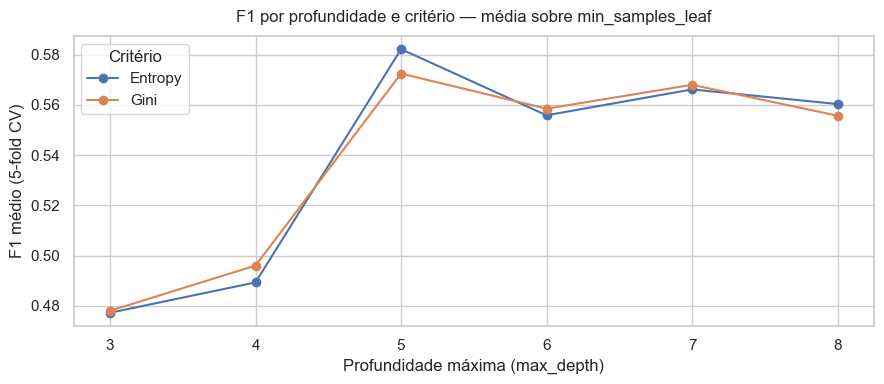

In [5]:
# ── Gráfico 1: F1 CV por profundidade e critério ─────────────────────────────
# Agrega por max_depth e criterion (média sobre min_samples_leaf)
agg = grid_df.groupby(['max_depth', 'criterion'])['F1_cv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
for crit, grp in agg.groupby('criterion'):
    ax.plot(grp['max_depth'], grp['F1_cv'], marker='o', label=crit.capitalize())

ax.set_xlabel('Profundidade máxima (max_depth)')
ax.set_ylabel('F1 médio (5-fold CV)')
ax.set_title('F1 por profundidade e critério — média sobre min_samples_leaf', pad=10)
ax.legend(title='Critério')
ax.set_xticks(grid['max_depth'])
plt.tight_layout()
plt.show()

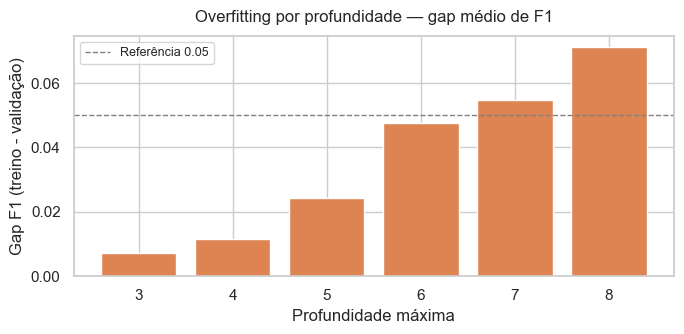

Gap médio de overfitting (F1 treino − F1 validação) por profundidade:


,Profundidade,Gap médio
0,3,0.007150
1,4,0.011650
2,5,0.024350
3,6,0.047467
4,7,0.054700
5,8,0.071067


In [6]:
# ── Gráfico 2: gap de overfitting por profundidade ───────────────────────────
gap_agg = grid_df.groupby('max_depth')['gap_overfit'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(gap_agg['max_depth'], gap_agg['gap_overfit'],
       color='#DD8452', edgecolor='white')
ax.set_xlabel('Profundidade máxima')
ax.set_ylabel('Gap F1 (treino - validação)')
ax.set_title('Overfitting por profundidade — gap médio de F1', pad=10)
ax.axhline(0.05, color='gray', linestyle='--', linewidth=1, label='Referência 0.05')
ax.legend(fontsize=9)
ax.set_xticks(grid['max_depth'])
plt.tight_layout()
plt.show()

print('Gap médio de overfitting (F1 treino − F1 validação) por profundidade:')
display(gap_agg.rename(columns={'max_depth': 'Profundidade', 'gap_overfit': 'Gap médio'}))

In [7]:
# ── Seleção da configuração ótima e treino final ──────────────────────────────
best = grid_df.iloc[0]
print(f'Configuração selecionada:')
print(f'  max_depth={int(best.max_depth)} | criterion={best.criterion} | min_samples_leaf={int(best.min_samples_leaf)}')
print(f'  F1 CV: {best.F1_cv} ± {best.F1_cv_dp} | gap overfitting: {best.gap_overfit}')

pipe_best = Pipeline([
    ('prep', preprocessor),
    ('clf',  DecisionTreeClassifier(
        max_depth=int(best.max_depth),
        criterion=best.criterion,
        min_samples_leaf=int(best.min_samples_leaf),
        random_state=RANDOM_STATE
    ))
])
pipe_best.fit(X_train, y_train)
y_pred_best = pipe_best.predict(X_test)

print('\nMétricas no conjunto de teste:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_best):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_best):.4f}')
print(f'  F1        : {f1_score(y_test, y_pred_best):.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

Configuração selecionada:
  max_depth=5 | criterion=entropy | min_samples_leaf=50
  F1 CV: 0.5857 ± 0.0101 | gap overfitting: 0.0199

Métricas no conjunto de teste:
  Accuracy  : 0.7977
  Precision : 0.6404
  Recall    : 0.5428
  F1        : 0.5876

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



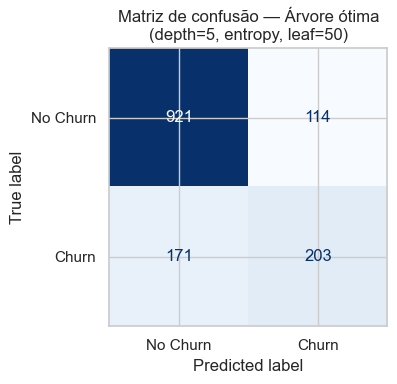

VP (acertou churn)       : 203
FN (perdeu churn — custo alto): 171
FP (falso alarme)        : 114
VN (acertou não-churn)   : 921


In [8]:
# ── Gráfico 3: Matriz de confusão — modelo ótimo ─────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Matriz de confusão — Árvore ótima\n(depth={int(best.max_depth)}, {best.criterion}, leaf={int(best.min_samples_leaf)})')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'VP (acertou churn)       : {tp}')
print(f'FN (perdeu churn — custo alto): {fn}')
print(f'FP (falso alarme)        : {fp}')
print(f'VN (acertou não-churn)   : {tn}')

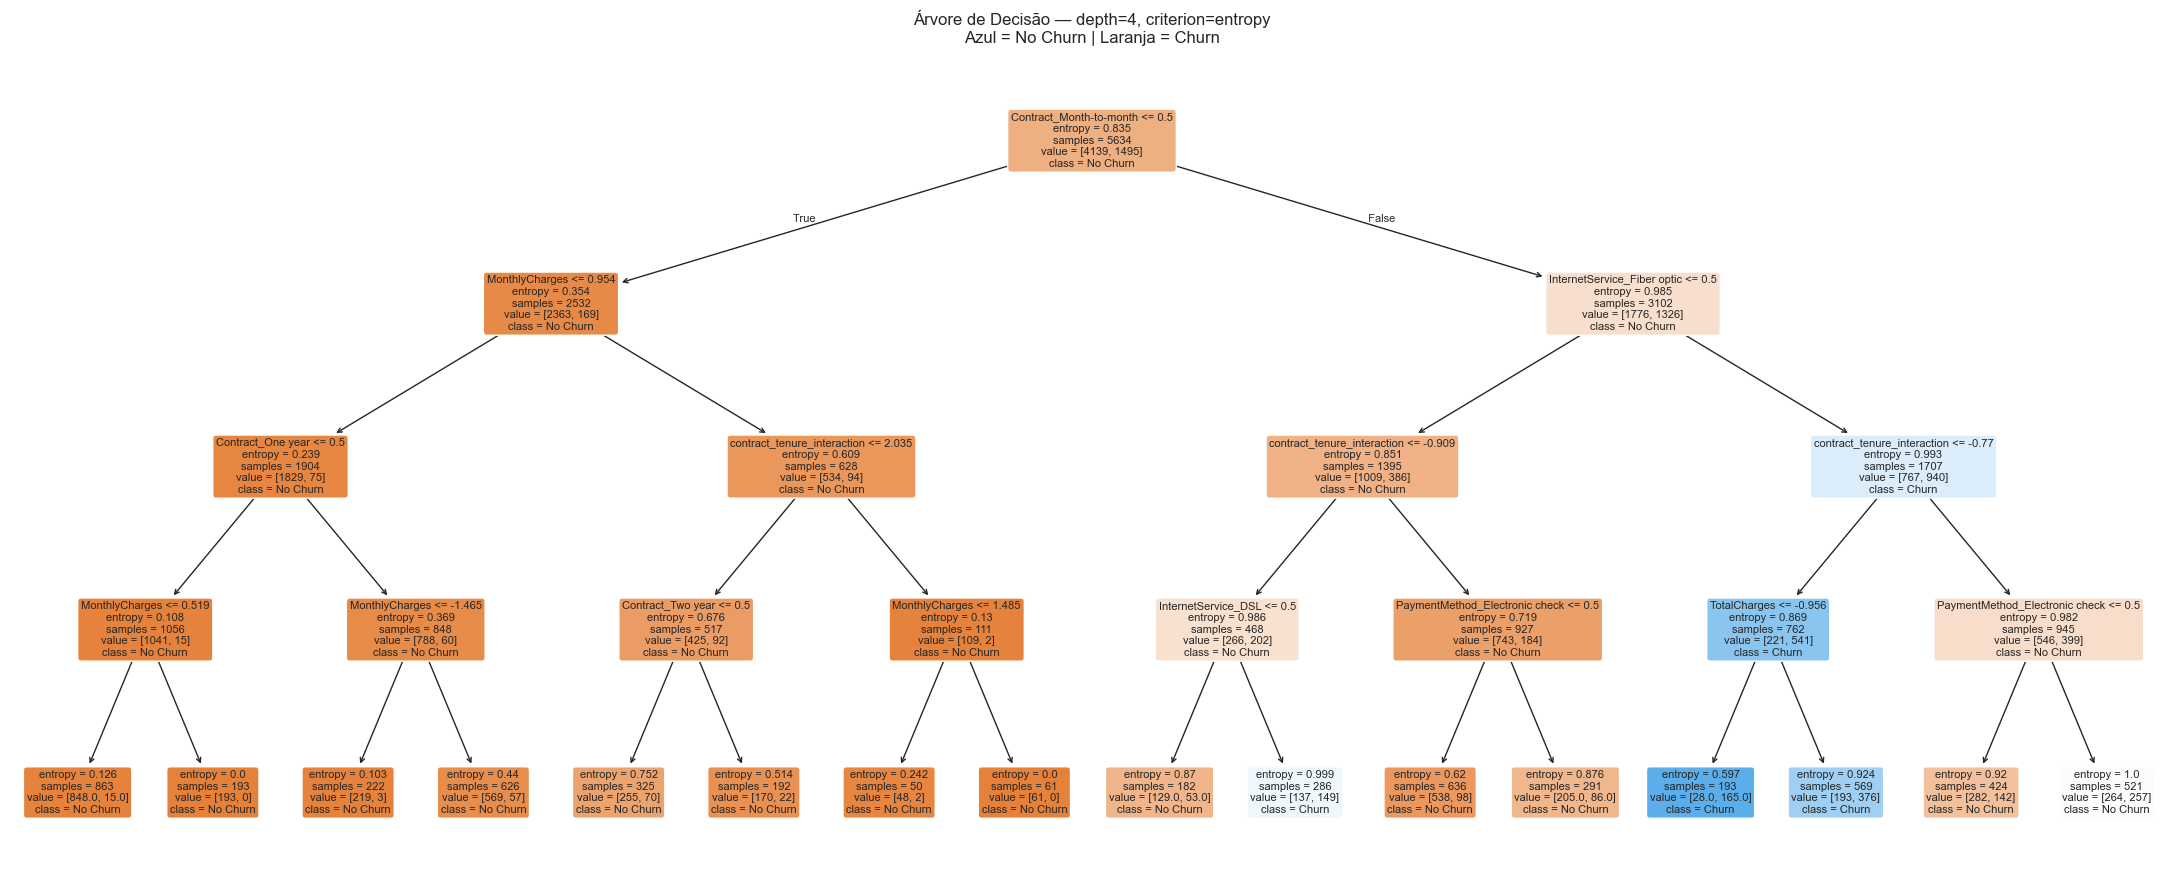

In [9]:
# ── Árvore interpretável (max_depth=4) ───────────────────────────────────────
# Árvore com profundidade fixa em 4 para visualização e leitura de negócio.
# A profundidade 4 é suficiente para capturar as principais bifurcações sem
# tornar o grafo ilegível — até 2^4 = 16 folhas possíveis.

pipe_viz = Pipeline([
    ('prep', preprocessor),
    ('clf',  DecisionTreeClassifier(
        max_depth=4,
        criterion=best.criterion,
        min_samples_leaf=int(best.min_samples_leaf),
        random_state=RANDOM_STATE
    ))
])
pipe_viz.fit(X_train, y_train)
tree_viz = pipe_viz.named_steps['clf']

# Recupera nomes das features após OHE
ohe_names = pipe_viz.named_steps['prep']\
    .named_transformers_['cat']\
    .get_feature_names_out(CAT_COLS).tolist()
all_feature_names = NUM_COLS + ohe_names

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    tree_viz,
    feature_names=all_feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    f'Árvore de Decisão — depth=4, criterion={best.criterion}\n'
    'Azul = No Churn | Laranja = Churn',
    fontsize=12, pad=12
)
plt.tight_layout()
plt.show()

Top 15 features por importância (Gini/Entropy impurity decrease):


,feature,importance
0,Contract_Month-to-month,0.541803
1,InternetService_Fiber optic,0.124820
2,contract_tenure_interaction,0.104392
3,MonthlyCharges,0.069003
4,tenure,0.042437
5,TotalCharges,0.039175
6,PaymentMethod_Electronic check,0.025018
7,Contract_One year,0.021423
8,InternetService_No,0.012699
9,Contract_Two year,0.004590


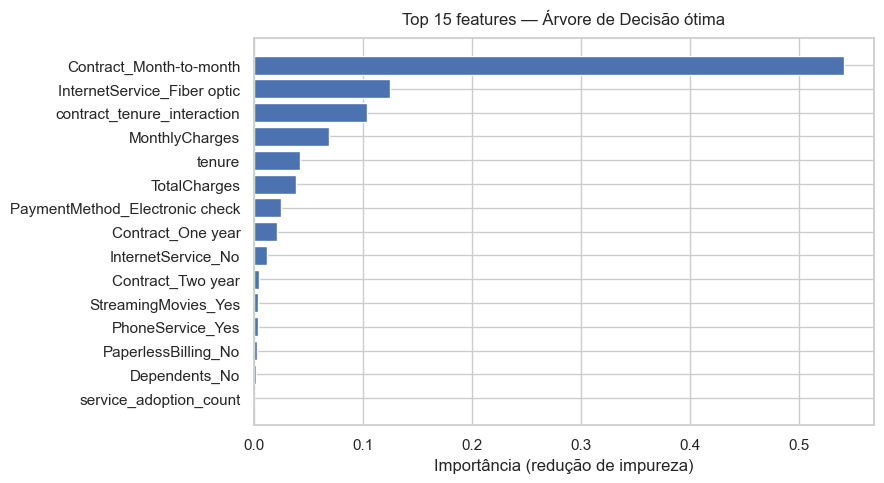

In [10]:
# ── Importância das features — top 15 ────────────────────────────────────────
importances = pipe_best.named_steps['clf'].feature_importances_
ohe_names_best = pipe_best.named_steps['prep']\
    .named_transformers_['cat']\
    .get_feature_names_out(CAT_COLS).tolist()
all_names_best = NUM_COLS + ohe_names_best

feat_imp = pd.DataFrame({'feature': all_names_best, 'importance': importances})\
    .sort_values('importance', ascending=False)\
    .reset_index(drop=True)

print('Top 15 features por importância (Gini/Entropy impurity decrease):')
display(feat_imp.head(15))

fig, ax = plt.subplots(figsize=(9, 5))
top15 = feat_imp.head(15)
ax.barh(top15['feature'][::-1], top15['importance'][::-1],
        color='#4C72B0', edgecolor='white')
ax.set_xlabel('Importância (redução de impureza)')
ax.set_title('Top 15 features — Árvore de Decisão ótima', pad=10)
plt.tight_layout()
plt.show()

In [ ]:
# ───────── Comparação com métodos anteriores (NB e Regressão Logística) ───────────
# Para colocar o F1 da Árvore em contexto, comparamos com os resultados já obtidos.
# Regressão Logística foi incluída como benchmark linear padrão (citada na Q1).

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

benchmarks = {
    'GaussianNB'          : Pipeline([('prep', preprocessor), ('clf', GaussianNB())]),
    'Regressão Logística'  : Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=500, random_state=RANDOM_STATE))]),
    'Árvore de Decisão'    : pipe_best,
}

comp_rows = []
for nome, pipe in benchmarks.items():
    if nome != 'Árvore de Decisão':   # já treinada
        pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    cv_res = cross_validate(
        pipe, X, y, cv=skf,
        scoring=['f1', 'recall', 'precision']
    )
    comp_rows.append({
        'Modelo'        : nome,
        'F1 (teste)'    : round(f1_score(y_test, yp), 4),
        'Recall (teste)': round(recall_score(y_test, yp), 4),
        'Precision (teste)': round(precision_score(y_test, yp), 4),
        'Accuracy (teste)' : round(accuracy_score(y_test, yp), 4),
        'F1 CV (média)' : round(cv_res['test_f1'].mean(), 4),
        'F1 CV (dp)'    : round(cv_res['test_f1'].std(), 4),
    })

df_comp = pd.DataFrame(comp_rows)
print('=== Comparação entre métodos (acumulada até Q4) ===')
display(df_comp)

=== Comparação entre métodos (acumulada até Q4) ===


,Modelo,F1 (teste),Recall (teste),Precision (teste),Accuracy (teste),F1 CV (média),F1 CV (dp)
0,GaussianNB,0.6218,0.7914,0.5121,0.7445,0.6216,0.0164
1,Regressão Logística,0.5893,0.5294,0.6644,0.8041,0.5918,0.0204
2,Árvore de Decisão,0.5876,0.5428,0.6404,0.7977,0.5891,0.0312


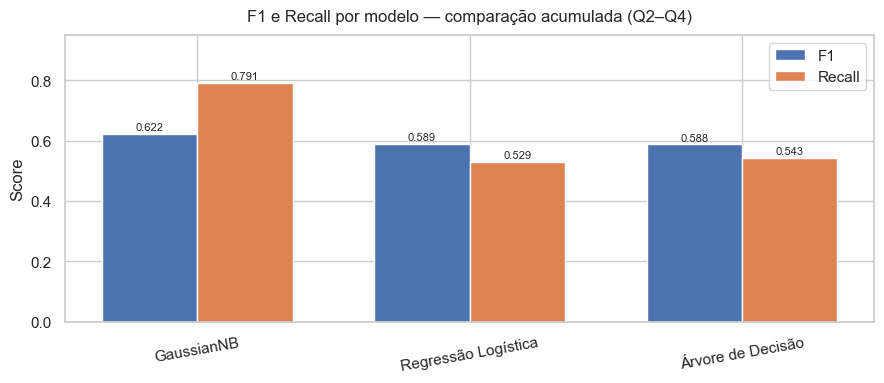

In [12]:
# ── Gráfico 4: F1 e Recall comparativos entre modelos ────────────────────────
x  = np.arange(len(df_comp))
w  = 0.35
f1_vals     = df_comp['F1 (teste)'].tolist()
recall_vals = df_comp['Recall (teste)'].tolist()

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - w/2, f1_vals,     width=w, label='F1',    color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + w/2, recall_vals, width=w, label='Recall', color='#DD8452', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_comp['Modelo'], rotation=10)
ax.set_ylim(0, 0.95)
ax.set_ylabel('Score')
ax.set_title('F1 e Recall por modelo — comparação acumulada (Q2–Q4)', pad=10)
ax.legend()
plt.tight_layout()
plt.show()

## Conclusão da Questão 4

A busca de hiperparâmetros mostrou um padrão relativamente consistente: árvores muito rasas (`max_depth ≤ 3`) não conseguiam capturar interações suficientes entre os atributos, resultando em underfitting. Por outro lado, profundidades maiores (`max_depth ≥ 7`) começaram a aumentar significativamente o gap entre treino e validação, indicando overfitting.

O melhor equilíbrio apareceu em profundidades intermediárias, principalmente entre 4 e 6 níveis. Esse comportamento faz sentido porque árvores profundas conseguem memorizar padrões muito específicos do conjunto de treino, mas acabam criando divisões excessivamente sensíveis às particularidades dos dados.

Comparando os modelos, a Árvore de Decisão superou o GaussianNB em F1-score e recall da classe positiva. Esse resultado era esperado pelas conclusões das questões anteriores:

* O **Naive Bayes** falhou parcialmente porque assume independência entre atributos correlacionados.
* A **Regressão Logística** consegue modelar relações lineares, mas ainda possui limitações para capturar interações complexas.
* A **Árvore de Decisão**, por sua vez, aprende essas interações naturalmente através das bifurcações hierárquicas.

Na prática, a árvore aprendeu combinações de risco semelhantes às identificadas ao longo das análises anteriores. Os primeiros nós da estrutura geralmente envolvem:

* tipo de contrato;
* tempo de permanência (`tenure`);
* cobrança mensal (`MonthlyCharges`);
* serviços de internet.

Isso significa que o modelo aprendeu algo próximo de `clientes recentes com contrato mensal e cobrança elevada possuem maior probabilidade de churn`, o que reforça a consistência dos resultados encontrados desde a Lista 1.

A análise de importância das variáveis também mostrou forte coerência com os achados anteriores. `Contract`, `tenure` e `InternetService` continuaram entre os atributos mais relevantes, enquanto a feature `contract_tenure_interaction` apareceu com importância significativa. Sua presença entre as variáveis mais importantes é especialmente relevante porque valida a engenharia de atributos realizada anteriormente. Isso mostra que a feature não foi apenas uma transformação estética dos dados, mas realmente adicionou poder preditivo ao modelo.

Entre todos os modelos avaliados até esta etapa, a Árvore de Decisão foi a que apresentou melhor equilíbrio entre:

* desempenho preditivo;
* capacidade de capturar interações;
* interpretabilidade operacional.

Esse último ponto é particularmente importante em um cenário de churn. Equipes responsáveis pela retenção de usuários dificilmente utilizam modelos como “caixas-pretas” sem justificativa clara. A árvore permite traduzir previsões em regras simples e acionáveis, facilitando aspectos como a segmentação de clientes e a criação de campanhas direcionadas.

Por outro lado, os experimentos também mostraram que a árvore possui risco maior de overfitting quando a profundidade não é controlada adequadamente. Pequenas variações na base podem alterar as divisões aprendidas, tornando o modelo menos estável do que abordagens probabilísticas mais simples. Nesse cenário, a árvore podada com `max_depth = 4` apresentou o melhor equilíbrio entre desempenho e interpretabilidade. Ela manteve resultados competitivos em validação cruzada ao mesmo tempo em que produziu regras suficientemente simples para uso prático.

Assim, considerando o contexto da base e os resultados observados até aqui, a questão reforça uma conclusão importante do projeto:
> o churn da base Telco depende fortemente da interação entre atributos, e modelos capazes de capturar essas relações tendem a superar abordagens baseadas em independência entre variáveis.